In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

In [2]:
np.random.seed(123)

n_samples = 8000
n_noise = 27  # столько шумовых признаков

# --- Сигнальные признаки (3 шт.) ---
# trace_width_min: минимальная ширина проводника
# класс 4: mean=175, std=10
# класс 3: mean=165, std=10
# разница = 10, std = 10 → overlap = 1.0

sig1_4 = np.random.normal(175, 10, n_samples // 2)
sig1_3 = np.random.normal(165, 10, n_samples // 2)

# layer_alignment: точность совмещения слоёв
# класс 4: mean=100, std=15
# класс 3: mean=120, std=15
# разница = 20, std = 15 → overlap = 1.33

sig2_4 = np.random.normal(100, 15, n_samples // 2)
sig2_3 = np.random.normal(120, 15, n_samples // 2)

# impedance_deviation: отклонение волнового сопротивления
# класс 4: mean=2.5, std=1.2
# класс 3: mean=5.0, std=1.5
# разница = 2.5, std ≈ 1.35 → overlap ≈ 1.85

sig3_4 = np.random.normal(2.5, 1.2, n_samples // 2)
sig3_3 = np.random.normal(5.0, 1.5, n_samples // 2)

# --- Таргет ---
y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

# --- Шумовые признаки (27 шт.) ---
noise_params = [
    (35.0, 5.0),    # copper_thickness
    (0.2, 0.05),    # dielectric_thickness
    (3.5, 0.5),     # dielectric_const
    (0.01, 0.005),  # loss_tangent
    (25.0, 5.0),    # solder_mask_thickness
    (3.0, 1.0),     # solder_mask_viscosity
    (30.0, 5.0),    # exposure_time
    (150.0, 20.0),  # lamination_temp
    (2.0, 0.5),     # lamination_pressure
    (2.0, 0.3),     # etching_speed
    (45.0, 5.0),    # etching_temp
    (150.0, 20.0),  # etching_concentration
    (20.0, 5.0),    # drill_speed
    (0.3, 0.1),     # drill_diameter
    (120.0, 20.0),  # drill_temperature
    (15.0, 5.0),    # electroless_time
    (40.0, 5.0),    # electroless_temp
    (5.0, 1.0),     # plating_ph
    (3.0, 0.5),     # plating_current
    (1.5, 0.5),     # surface_roughness
    (90.0, 5.0),    # surface_gloss
    (2.0, 1.0),     # pore_count
    (1.0, 0.5),     # mask_peeling
    (0.2, 0.1),     # contour_deviation
    (85.0, 10.0),   # etching_uniformity
    (20.0, 5.0),    # press_time
    (170.0, 15.0),  # press_temperature
]

noise_columns = [
    'copper_thickness', 'dielectric_thickness', 'dielectric_const', 
    'loss_tangent', 'solder_mask_thickness', 'solder_mask_viscosity',
    'exposure_time', 'lamination_temp', 'lamination_pressure',
    'etching_speed', 'etching_temp', 'etching_concentration',
    'drill_speed', 'drill_diameter', 'drill_temperature',
    'electroless_time', 'electroless_temp', 'plating_ph',
    'plating_current', 'surface_roughness', 'surface_gloss',
    'pore_count', 'mask_peeling', 'contour_deviation',
    'etching_uniformity', 'press_time', 'press_temperature'
]

noise_data = {}
for i, (mean, std) in enumerate(noise_params):
    noise_data[noise_columns[i]] = np.random.normal(mean, std, n_samples)

# --- Собираем DataFrame ---
feature_names = ['trace_width_min', 'layer_alignment', 'impedance_deviation'] + noise_columns

df = pd.DataFrame(noise_data)
df['trace_width_min'] = np.concatenate([sig1_3, sig1_4])
df['layer_alignment'] = np.concatenate([sig2_3, sig2_4])
df['impedance_deviation'] = np.concatenate([sig3_3, sig3_4])
df['pcb_class'] = y

# Перемешаем строки
df = df.sample(frac=1, random_state=123).reset_index(drop=True)
df['pcb_class'] = df['pcb_class'].astype(int)
df

,copper_thickness,dielectric_thickness,dielectric_const,loss_tangent,solder_mask_thickness,solder_mask_viscosity,exposure_time,lamination_temp,lamination_pressure,etching_speed,...,pore_count,mask_peeling,contour_deviation,etching_uniformity,press_time,press_temperature,trace_width_min,layer_alignment,impedance_deviation,pcb_class
0,28.238092,0.264852,3.827787,0.003016,20.247350,4.533526,29.634389,123.124212,2.720183,1.595218,...,1.583378,1.757773,0.182340,86.255972,20.361023,162.830546,165.662485,114.554502,2.375068,1
1,34.005490,0.254960,3.465241,0.008726,22.804186,1.320754,26.999289,149.071583,1.695870,1.637349,...,0.687521,1.354180,0.185194,96.978103,23.587796,159.061940,180.598035,130.532477,4.033246,0
2,34.125290,0.105633,3.440651,0.010619,15.470630,1.868183,21.913226,128.136175,1.924632,1.808905,...,1.994378,1.252346,0.116590,81.487326,21.711941,176.639810,187.024730,94.169560,4.381722,0
3,31.507780,0.207583,3.283209,0.020182,26.276181,3.988957,42.790616,149.004793,2.263158,2.005790,...,4.094667,0.902975,0.123003,91.907642,15.223221,172.578764,183.354116,106.471205,2.190335,1
4,27.402728,0.263281,4.114740,0.008232,23.944369,3.052585,29.918971,169.598902,2.378198,1.970804,...,1.511082,-0.103578,0.133053,64.447874,15.259929,177.134963,185.939699,103.955653,0.382699,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,26.994437,0.163320,3.615004,0.012239,18.976697,3.558999,24.383270,140.599297,2.352487,2.212149,...,2.881953,1.800024,0.342765,91.559156,8.907755,201.709388,167.272913,79.925909,1.472065,1
7996,41.384195,0.192054,4.352819,0.011740,30.162185,2.326535,30.042051,131.221859,1.832546,2.122353,...,2.257882,0.434027,0.399183,88.316694,25.176497,184.047889,141.259771,132.624749,6.129970,0
7997,38.429296,0.203591,2.452545,0.010913,17.459467,0.463396,30.843955,143.649381,2.079327,2.278462,...,0.094529,0.854548,0.232257,75.310661,17.724974,177.288901,155.360571,108.978741,3.986310,0
7998,41.596557,0.231309,2.840694,0.013300,23.774220,5.172348,29.608480,162.600893,1.967839,1.455399,...,0.345542,0.715152,0.042979,89.423464,13.635620,168.461438,173.169134,77.190154,2.977593,1


k = 5
k = 15
k = 25
k = 35
k = 45
k = 55
k = 65
k = 75
k = 85
k = 95
k = 105
k = 115
k = 125
k = 135
k = 145
k = 155
k = 165
k = 175
k = 185
k = 195


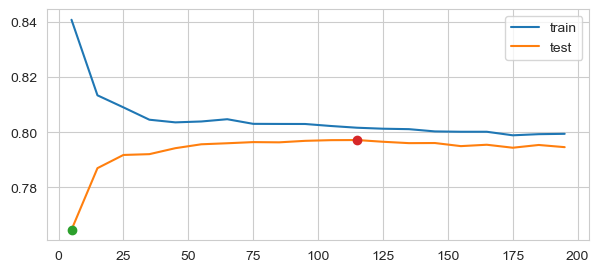

Дефолтный скор: 0.7646
Максимальный скор: 0.7972 при k = 115
Прирост скора: 0.0326


In [4]:
X = df.drop(columns = ['pcb_class'])
y = df['pcb_class']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(2.5*len(X)/100), 10):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*10 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 15
k = 25
k = 35
k = 45
k = 55
k = 65
k = 75
k = 85
k = 95
k = 105
k = 115
k = 125
k = 135
k = 145
k = 155
k = 165
k = 175
k = 185
k = 195


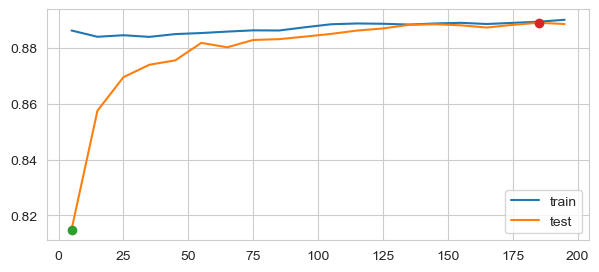

Дефолтный скор: 0.8149
Максимальный скор: 0.889 при k = 185
Прирост скора: 0.0742


In [5]:
X = df.drop(columns = ['pcb_class'])
y = df['pcb_class']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(2.5*len(X)/100), 10):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*10 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

In [ ]:
# df.to_csv('data/PCB.scv', index=False)